# Setup

In [1]:
# base
import os
import sys
import gc
import re
import warnings
import logging
import pickle
from time import ctime, time
from datetime import timedelta
from collections import Counter
import itertools
import session_info

# data manipulation
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from rpy2.robjects.conversion import localconverter

# single cell
import anndata as ad
import scanpy as sc

# custom
sys.path.insert(0, '../..')
from single_cell.R import *
from single_cell.preprocess import *
from single_cell.plot import *
from single_cell.analysis import *
from utils import *

warnings.simplefilter("ignore", FutureWarning)
warnings.simplefilter("ignore", UserWarning)
warnings.simplefilter("ignore", RuntimeWarning)
warnings.simplefilter("ignore", pd.errors.DtypeWarning)
warnings.simplefilter("ignore", pd.errors.PerformanceWarning)
mlogger = logging.getLogger("matplotlib")
mlogger.setLevel(logging.ERROR)

CORES = 10
DATADIR = Path("../../../data") / "processed" / "single_cell" / "combined"
REFDIR = Path("../../../references")
SUBSETS_DIR = DATADIR / "subsets"

METADATA = [
    "Diet",
    "Age",
    "Depot",
    "Sex",
]
DOUBLETMETHODS = ["scDblFinder", "DoubletFinder", "doubletdetection", "scrublet"]
GLOBAL_INT_KEY = "global_INT_scvi-hvg-Identifier"

%load_ext autoreload
%load_ext rpy2.ipython
%matplotlib inline
converter = get_converter()
# R_preload()
mpl.rcdefaults()
gc.collect()

session_info.show()

/mnt/DATA/home/ethung/projects/spatial_seq/.pixi/envs/main/lib/python3.12/site-packages/phenograph/cluster.py:13: DeprecationWarning: Please import `spmatrix` from the `scipy.sparse` namespace; the `scipy.sparse.base` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.sparse.base import spmatrix
/mnt/DATA/home/ethung/projects/spatial_seq/.pixi/envs/main/lib/python3.12/site-packages/session_info/main.py:213: DeprecationWarning: The '__version__' attribute is deprecated and will be removed in MarkupSafe 3.1. Use feature detection, or `importlib.metadata.version("markupsafe")`, instead.
/mnt/DATA/home/ethung/projects/spatial_seq/.pixi/envs/main/lib/python3.12/site-packages/session_info/main.py:213: DeprecationWarning: Accessing jsonschema.__version__ is deprecated and will be removed in a future release. Use importlib.metadata directly to query for jsonschema's version.
/mnt/DATA/home/ethung/projects/spatial_seq/.pixi/envs/main/lib/python3.12/site-packages/session_in

In [2]:
CELLTYPE_ADDON = "fibro"
CLUSTER_KEY = "leiden_fibro"
DE_KEY = "fibro_DEGs"
SELECT_RES = [0.6]
INT_KEY = "INT_harmony-global_PCA-hvg-Identifier"
contam_resolutions = np.arange(1, 6) / 5
resolutions = np.arange(1, 10) / 10

celltype_markers_concise = {
    "Adipocyte": ["Adipoq"],
    "Fibroblast": ["Pdgfra"],
    "Mesothlial": ["Wt1"],
    "Endothelial": ["Cdh5"],
    "Smooth Muscle Cell": ["Myocd"],
    "Pericyte": ["Enpep"],
    "Epithelial 1": ["Dcdc2a"],
    "Epithelial 2": ["Erbb4"],
    "Macrophage": ["Adgre1"],
    "Dendritic Cell": ["Flt3"],
    "Neutrophil": ["Csf3r"],
    "Mast Cell": ["Cpa3"],
    "B Cell": ["Ms4a1"],
    "T Cell": ["Cd3d"],
    "NK Cell": ["Klrd1"],
}

celltype_markers_full = {
    "Adipocyte": ["Adipoq"],
    "Fibroblast": ["Pdgfra", "Col1a1"],
    "Mesothlial": ["Wt1"],
    "Endothelial": ["Cdh5", "Cldn5"],
    "Smooth Muscle Cell": ["Myocd", "Myh11"],
    "Pericyte": ["Enpep", "Pdgfrb"],
    "Epithelial": ["Dcdc2a", "Erbb4", "Epcam"],
    "Macrophage": ["Adgre1", "Itgam"],
    "Dendritic Cell": ["Flt3"],
    "Neutrophil": ["Csf3r", "S100a8", "S100a9"],
    "Mast Cell": ["Cpa3"],
    "B Cell": ["Ms4a1"],
    "T Cell": ["Cd3d", "Cd3e"],
    "NK Cell": ["Klrd1", "Ncr1"],
}

# Load Data

In [ ]:
adata = sc.read_h5ad(DATADIR / "eWAT_Male.h5ad")
# adata = ad.read_zarr(DATADIR / "eWAT_Male.zarr")
adata

In [ ]:
# subset
adata_fibro = adata[adata.obs["celltype"] == "Fibroblast"].copy()
del adata_fibro.uns, adata_fibro.varm, adata_fibro.obsp, adata_fibro.obsm
# Filter_QC(adata_fibro)
# Visualize(adata_fibro, key=f"{CELLTYPE_ADDON}_global", obsm=GLOBAL_INT_KEY)

# Cleaning

In [ ]:
adata_fibro = sc.read_h5ad(SUBSETS_DIR / f"{CELLTYPE_ADDON}_reintegrated.h5ad")

all_integrations = [
    f"INT_{method}-{CELLTYPE_ADDON}_PCA-hvg-{N}-{batch}"
    for method in ["harmony"]#, "scanorama"]
    for N in [200, 500, 1000, 1500, 2000]
    for batch in ["Dataset", "Identifier"]
] + [
    f"INT_{method}-global_PCA-hvg-{batch}"
    for method in ["harmony"]#, "scanorama"]
    for batch in ["Dataset", "Identifier"]
]

## Reintegration

In [ ]:
temp = adata_fibro.copy()
scib.pp.reduce_data(temp, "Dataset", neighbors=False, overwrite_hvg=False)

f, axs = plt.subplots(3,1,figsize=(10,20), layout="constrained")
axs = axs.flatten()

for i, covariate in enumerate(["Dataset", "Identifier", "Age"]):
    # compute scores (Series with index in the desired order)
    PRC_Comp_scores = pd.Series(
        [ scib.metrics.pcr_comparison(
            temp,
            temp,
            covariate=covariate,
            embed=int_key,
            verbose=False)
          for int_key in tqdm(all_integrations) ],
        index = all_integrations
    )

    ax = axs[i]
    # pass explicit x (categories) and y (values), and set order to keep index order
    sns.barplot(x=PRC_Comp_scores.index,
                y=PRC_Comp_scores.values,
                order=PRC_Comp_scores.index,
                ax=ax,
                errorbar=None)   # disable errorbars if not needed

    # get the BarContainer that seaborn created and label it
    bars = ax.containers[0]               # seaborn stores bars here
    ax.bar_label(bars, fmt='%.3f', padding=2)

    ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha="right")
    ax.set_title("PCR Comparison Scores")
    ax.set_ylabel(f"Scaled Δ PCR Variance\n(`{covariate}` covariate)")
    ax.set_xlabel("resolution")

In [ ]:
# # compare all integrations
# r, c = 2, 5
# f, axs = plt.subplots(r, c, figsize=(8 * c, 6 * r), layout="constrained")
# axs = axs.flatten()
# int_check = "Dataset"

# for i, dr_key in enumerate(
#     [
#         f"UMAP_INT_{method}-{f"PCA_{CELLTYPE_ADDON}-hvg-{N}"}-{batch}"
#         for method in ["harmony"]
#         for batch in ["Dataset", "Identifier"]
#         for N in [500,1000,2000]
#         # for modifier in ["hvg", "all"]
#     ]
# ):
#     sc.pl.embedding(
#         adata_fibro,
#         basis=dr_key,
#         color=int_check,
#         alpha=1,
#         ax=axs[i],
#         show=False,
#         legend_loc="none" if i < len(axs) - 1 else "right margin",
#         palette=create_palette(8)
#     )

#     if i == len(axs) - 1:
#         legend_info = axs[-1].get_legend_handles_labels()
#         f, ax = plt.subplots()
#         ax.legend(*legend_info)
#         ax.axis("off")

#         axs[-1].get_legend().remove()

In [ ]:
# for i, dr_key in enumerate(
#     [
#         f"UMAP_{CELLTYPE_ADDON}_INT_{method}-{modifier}-{batch}"
#         # f"UMAP_INT_{method}-{f"PCA_{CELLTYPE_ADDON}-hvg-{N}"}-{batch}"
#         for method in ["harmony"]
#         for batch in ["Dataset", "Identifier"]
#         # for N in [200,500,1000,1500,2000]
#         for modifier in ["hvg", "all"]
#     ]
# ):
#     check_integration(
#         adata_fibro, "Dataset",
#         embeddings=[dr_key],
#         f=plt.figure(figsize=(18,10), layout="constrained"),
#         nrow=3)

In [ ]:
check_integration(
    adata_fibro, "Dataset",
    embeddings=[f"UMAP_{INT_KEY}"],
    f=plt.figure(figsize=(18,10), layout="constrained"),
    nrow=3)

## Clean contaminants
- multiplets/contamination with Adgre1 (F4/80) or Cdh5 + Pdgfra & Wt1 expression (1373)
- small, dataset-specific clusters with primarily mito/ribo/unknown genes as DEGs

In [ ]:
%autoreload 2
# recluster
cluster = True

if cluster is True:
    Visualize(adata_fibro, key=INT_KEY, obsm=INT_KEY, umap=False)
    # Cluster(adata_fibro, f"neighbors_{INT_KEY}", CLUSTER_KEY, contam_resolutions, int_key=INT_KEY)

# plot clusters
for embedding in [f"UMAP_{INT_KEY}", f"LocalMAP_{INT_KEY}"]:
    r, c = 2, 3
    f, axs = plt.subplots(r, c, figsize=(8 * c, 6 * r), layout="constrained")
    axs = axs.flatten()

    for i, res in enumerate(tqdm(contam_resolutions)):
        res_key = f"{CLUSTER_KEY}_{res}"
        cluster_c = color_gen(adata_fibro.obs[res_key].cat.categories)
        adata_fibro.obs[res_key] = (
            adata_fibro.obs[res_key].astype(int).astype("category")
        )

        sc.pl.embedding(
            adata_fibro,
            basis=embedding,
            color=res_key,
            ax=axs[i],
            show=False,
            legend_loc="on data",
            legend_fontoutline=2,
            legend_fontsize=15,
            palette=cluster_c,
        )
        axs[i].annotate(
            f"n = {adata_fibro.shape[0]}",
            size=15,
            fontweight="bold",
            xy=(0.98, 0.02),
            xycoords="axes fraction",
            horizontalalignment="right",
            verticalalignment="bottom",
        )

f = plot_cluster_trees(
    adata_fibro,
    [f"{CLUSTER_KEY}_{res}" for res in contam_resolutions],
    threshold=0.02,
    x_spacing=2,
    y_spacing=1,
)

In [ ]:
# counts/breakdowns
for col in adata_fibro.obs.columns:
    if CLUSTER_KEY in col:
        adata_fibro.obs[col] = adata_fibro.obs[col].astype(int).astype("category")

r, c = 2,3

# count barplots
f, axs = plt.subplots(r, c, figsize=(10 * c, 5 * r), layout="constrained")
axs = axs.flatten()
for i, res in enumerate(contam_resolutions):
    res_key = f"{CLUSTER_KEY}_{res}"
    plot_cluster_counts(adata_fibro, res_key, ax=axs[i])
axs[-1].set_visible(False)

# percentage breakdowns
for col in ["Dataset"]:
    f, axs = plt.subplots(r, c, figsize=(10 * c, 6 * r), layout="constrained")
    axs = axs.flatten()
    for i, res in enumerate(contam_resolutions):
        res_key = f"{CLUSTER_KEY}_{res}"
        plot_cluster_stackedbarplot(adata_fibro, res_key, col, pct=True, ax=axs[i])
    f.suptitle(col + " Split", size=30)
axs[-1].set_visible(False)

In [ ]:
# best resolution for viewing contamination
contam_res = 1.0
embedding = f"UMAP_{INT_KEY}"
contam_clusters = f"{CLUSTER_KEY}_{0.8}"
adata_fibro.obs[contam_clusters] = (
    adata_fibro.obs[contam_clusters].astype(int).astype("category")
)

sc.pl.embedding(
    adata_fibro,
    basis=embedding,
    color=contam_clusters,
    show=False,
    legend_loc="on data",
    legend_fontoutline=2,
    legend_fontsize=15,
    palette=color_gen(adata_fibro.obs[contam_clusters].cat.categories),
)
axs[i].annotate(
    f"n = {adata_fibro.shape[0]}",
    size=15,
    fontweight="bold",
    xy=(0.98, 0.02),
    xycoords="axes fraction",
    horizontalalignment="right",
    verticalalignment="bottom",
)

In [ ]:
clear_uns(adata_fibro, "colors")
plot_violinplot(adata_fibro, contam_clusters, celltype_markers_full, y_bracket_fontsize=8, title="possible multiplets")

In [ ]:
f = plot_cluster_trees(
    adata_fibro,
    [f"{CLUSTER_KEY}_{res}" for res in contam_resolutions],
    markers=celltype_markers_full["Macrophage"],
    title="likely Macrophage",
    show_fraction=True,
    threshold=0.02,
    x_spacing=2,
    y_spacing=1,
)

f = plot_cluster_trees(
    adata_fibro,
    [f"{CLUSTER_KEY}_{res}" for res in contam_resolutions],
    markers=celltype_markers_full["Endothelial"],
    title="likely Endothelial",
    show_fraction=True,
    threshold=0.02,
    x_spacing=2,
    y_spacing=1,
)

In [ ]:
# original subclusters

# change to string for DEGs
for col in adata_fibro.obs.columns:
    if CLUSTER_KEY in col:
        adata_fibro.obs[col] = adata_fibro.obs[col].astype(str).astype("category")

for res in [contam_res]:
    res_key = contam_clusters
    de_key = f"{contam_clusters}_DEGs"
    n_clust = len(adata_fibro.obs[res_key].unique())

    # calculate DEGs
    task_start = stopwatch(f"`{res_key}` DEGs", time())
    clear_uns(adata_fibro, de_key)
    sc.tl.rank_genes_groups(
        adata_fibro,
        groupby=res_key,
        key_added=de_key,
        use_raw=False,
        layer="normalized",
        method="wilcoxon",
    )
    stopwatch(f"`{res_key}` DEGs", task_start, mode=1)

    # plot DEGs
    top_genes = {}
    for group, df in sc.get.rank_genes_groups_df(
        adata_fibro, group=None, key=de_key
    ).groupby("group"):
        top_genes[group] = df["names"][:30].tolist()
    f, ax = plt.subplots(1, 1, figsize=(n_clust * 5, 5), layout="constrained")
    sc.pl.rank_genes_groups_dotplot(
        adata_fibro,
        groupby=res_key,
        key=de_key,
        # n_genes=20,
        var_names=top_genes,
        # standard_scale="var",
        values_to_plot="logfoldchanges",
        cmap="bwr",
        colorbar_title="log fold change",
        ax=ax,
        title=f"{res_key}_DEGs",
        vmin=-4,
        vmax=4,
    )

    sc.pl.rank_genes_groups_heatmap(
        adata_fibro,
        key=de_key,
        groupby=res_key,
        layer="normalized",
        n_genes=50,
    )
    sc.pl.rank_genes_groups(
        adata_fibro, key=de_key, n_genes=30, title=f"{res_key}_DEGs"
    )
clear_uns(adata_fibro,"DEGs")

In [ ]:
# remove junk!
c_remove = [7,10,12,13, 8,11]
print(f"Cells removed: {adata_fibro[adata_fibro.obs[contam_res].isin(c_remove)].shape[0]}")

adata_fibro = adata_fibro[
    ~(adata_fibro.obs[contam_res].isin(c_remove))
].copy()
print(adata_fibro.shape)

# change to string for DEGs
for col in adata_fibro.obs.columns:
    if CLUSTER_KEY in col:
        adata_fibro.obs[col] = adata_fibro.obs[col].astype(int).astype("category")

##### Spermatid aside

In [ ]:
method = "UCell"
gs_name = "GermCell"
module_score(
    adata_fibro,
    genesets={gs_name : ["Prm1", "Prm2", "Spz1", "Misfa", "Tcfl5", "Ddx4"]},
    method=method,
    zscore=False)
plot_violinplot(adata_fibro, f"{CLUSTER_KEY}_0.8", [f"{gs_name}_{method}"])

# module_score(adata, genesets={"germ cell" : ["Prm1", "Prm2", "Spz1", "Misfa", "Tcfl5", "Ddx4"]}, zscore=False)
# plot_violinplot(adata, f"celltype", ["germ cell_Seurat"])

f, ax = plt.subplots(1, 1, figsize=(15, 12))
sc.pl.embedding(
    adata_fibro,
    basis=f"UMAP_{INT_KEY}",
    color=f"{gs_name}_{method}",
    ax=ax,
    show=False,
    legend_loc="on data",
    legend_fontoutline=1.5,
    legend_fontsize=20,
    palette=cluster_c,
    cmap="Reds",
    size=15,
    vmin=0.5,
)
ax.annotate(
    f"n = {adata_fibro.shape[0]}",
    size=15,
    fontweight="bold",
    xy=(0.98, 0.02),
    xycoords="axes fraction",
    horizontalalignment="right",
    verticalalignment="bottom",
    )

## Clustering

In [ ]:
%autoreload 2
# recluster
cluster = False

if cluster is True:
    Cluster(adata_fibro, f"neighbors_{INT_KEY}", cluster_key=CLUSTER_KEY, resolutions=resolutions)

# plot clusters
for embedding in [f"UMAP_{INT_KEY}", f"LocalMAP_{INT_KEY}"]:
    r, c = 3, 3
    f, axs = plt.subplots(r, c, figsize=(8 * c, 6 * r), layout="constrained")
    axs = axs.flatten()

    for i, res in enumerate(tqdm(resolutions, desc=f"Plotting all clusters using in `{embedding}` space")):
        res_key = f"{CLUSTER_KEY}_{res}"
        cluster_c = color_gen(adata_fibro.obs[res_key].cat.categories)
        adata_fibro.obs[res_key] = (
            adata_fibro.obs[res_key].astype(int).astype("category")
        )

        sc.pl.embedding(
            adata_fibro,
            basis=embedding,
            color=res_key,
            ax=axs[i],
            show=False,
            legend_loc="on data",
            legend_fontoutline=2,
            legend_fontsize=15,
            palette=cluster_c,
        )
        axs[i].annotate(
            f"n = {adata_fibro.shape[0]}",
            size=15,
            fontweight="bold",
            xy=(0.98, 0.02),
            xycoords="axes fraction",
            horizontalalignment="right",
            verticalalignment="bottom",
        )

f = plot_cluster_trees(
    adata_fibro,
    [f"{CLUSTER_KEY}_{res}" for res in resolutions],
    threshold=0.03,
    node_size_range=(100, 2000),
    x_spacing=2,
    y_spacing=2,
    show_fraction=True,
)

In [ ]:
# metadata checks
embedding = f"UMAP_{INT_KEY}"

f = plt.figure(figsize=(9, 12), layout="constrained")
check_integration(
    adata_fibro,
    "Dataset",
    f,
    embeddings=[embedding],
    nrow=3,
)

f = plt.figure(figsize=(7, 10), layout="constrained")
check_integration(
    adata_fibro,
    "Diet",
    f,
    embeddings=[embedding],
    nrow=2,
)

In [ ]:
# counts/breakdowns
for col in adata_fibro.obs.columns:
    if CLUSTER_KEY in col:
        adata_fibro.obs[col] = adata_fibro.obs[col].astype(int).astype("category")

r, c = 3, 3

# count barplots
f, axs = plt.subplots(r, c, figsize=(10 * c, 5 * r), layout="constrained")
axs = axs.flatten()
for i, res in enumerate(resolutions):
    res_key = f"{CLUSTER_KEY}_{res}"
    plot_cluster_counts(adata_fibro, res_key, ax=axs[i])

# percentage breakdowns
for col in ["Dataset", "Diet"]:
    f, axs = plt.subplots(r, c, figsize=(10 * c, 6 * r), layout="constrained")
    axs = axs.flatten()
    for i, res in enumerate(resolutions):
        res_key = f"{CLUSTER_KEY}_{res}"
        plot_cluster_stackedbarplot(adata_fibro, res_key, col, pct=True, ax=axs[i])
    f.suptitle(col + " Split", size=30)

# Exploration

### Plot

In [ ]:
# counts/breakdowns
for col in adata_fibro.obs.columns:
    if CLUSTER_KEY in col:
        adata_fibro.obs[col] = adata_fibro.obs[col].astype(int).astype("category")

r, c = 1, len(SELECT_RES)
# count barplots
f, axs = plt.subplots(r, c, figsize=(10 * c, 5 * r), layout="constrained")
axs = axs.flatten()
for i, res in enumerate(SELECT_RES):
    res_key = f"{CLUSTER_KEY}_{res}"
    plot_cluster_counts(adata_fibro, res_key, ax=axs[i])

# percentage breakdowns
for col in ["Dataset", "Diet"]:
    f, axs = plt.subplots(r, c, figsize=(10 * c, 6 * r), layout="constrained")
    axs = axs.flatten()
    for i, res in enumerate(SELECT_RES):
        res_key = f"{CLUSTER_KEY}_{res}"
        plot_cluster_stackedbarplot(adata_fibro, res_key, col, pct=True, ax=axs[i])
    f.suptitle(col + " Split", size=30)

In [ ]:
f = clustree(
    adata_fibro,
    [f"{CLUSTER_KEY}_{res}" for res in SELECT_RES],
    edge_weight_threshold=0,
    x_spacing=3,
    y_spacing=0.5,
    node_size_range=(100, 1000),
    # show_fraction=True
)
f.set_figheight(3)

for embedding in [f"UMAP_{INT_KEY}", f"LocalMAP_{INT_KEY}"]:
    for res in tqdm(SELECT_RES):
        res_key = f"{CLUSTER_KEY}_{res:.1f}"
        cluster_c = color_gen(adata_fibro.obs[res_key].cat.categories)
        adata_fibro.obs[res_key] = adata_fibro.obs[res_key].astype(int).astype("category")

        f, ax = plt.subplots(1, 1, figsize=(15, 12))
        sc.pl.embedding(
            adata_fibro,
            basis=embedding,
            color=res_key,
            ax=ax,
            show=False,
            legend_loc="on data",
            legend_fontoutline=1.5,
            legend_fontsize=20,
            palette=cluster_c,
            size=15,
        )
        ax.annotate(
            f"n = {adata_fibro.shape[0]}",
            size=15,
            fontweight="bold",
            xy=(0.98, 0.02),
            xycoords="axes fraction",
            horizontalalignment="right",
            verticalalignment="bottom",
        )

### DEGs

In [ ]:
# run subclusters
RUN_DEG = True
# clear_uns(adata_fibro,"DEGs")

# change to string for DEGs
for col in adata_fibro.obs.columns:
    if CLUSTER_KEY in col:
        adata_fibro.obs[col] = adata_fibro.obs[col].astype(str).astype("category")



for res in SELECT_RES:
    res_key = f"{CLUSTER_KEY}_{res:.1f}"
    de_key = f"{DE_KEY}_{res:.1f}"
    n_clust = len(adata_fibro.obs[res_key].unique())

    # calculate DEGs
    if RUN_DEG is True:
        task_start = stopwatch(f"`{res_key}` DEGs", time())
        clear_uns(adata_fibro, de_key)
        sc.tl.rank_genes_groups(
            adata_fibro,
            groupby=res_key,
            key_added=de_key,
            use_raw=False,
            layer="normalized",
            method="wilcoxon",
        )
        stopwatch(f"`{res_key}` DEGs", task_start, mode=1)

    # plot DEGs
    N = 30
    # top_genes = {}
    # for group, df in sc.get.rank_genes_groups_df(
    #     adata_fibro, group=None, key=de_key
    # ).groupby("group"):
    #     top_genes[group] = df["names"][:N].tolist()
    f, ax = plt.subplots(1, 1, figsize=(n_clust * 5, 5), layout="constrained")
    sc.pl.rank_genes_groups_dotplot(
        adata_fibro,
        groupby=res_key,
        key=de_key,
        n_genes=N,
        # var_names=top_genes,
        # standard_scale="var",
        values_to_plot="logfoldchanges",
        cmap="bwr",
        colorbar_title="log fold change",
        ax=ax,
        title=f"{res_key}_DEGs",
        vmin=-4,
        vmax=4,
    )

    sc.pl.rank_genes_groups_heatmap(
        adata_fibro,
        key=de_key,
        groupby=res_key,
        layer="normalized",
        n_genes=50,
        cmap="viridis",
    )
    # sc.pl.rank_genes_groups(
    #     adata_fibro, key=de_key, n_genes=30, title=f"{res_key}_DEGs"
    # )

### Diet DEG by Cluster

In [ ]:
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

sample_key = "Identifier"
celltype_key = f"{CLUSTER_KEY}_0.6"
condition_key = "Diet"
covariates = ["Dataset"]
comparison = [condition_key, 'HFD', 'LFD']
pbulk_DEG_results = {}
quiet = True

# Pseudobulk DEGs
pdata = dc.pp.pseudobulk(
    adata_fibro,
    sample_col=sample_key,
    groups_col=celltype_key,
    layer='counts',
    mode='sum'
)
order_obs(pdata, "Diet", ["LFD", "HFD"])
print(pdata.obs[["psbulk_cells", "psbulk_counts"]].sort_values("psbulk_cells"))

# filter samples based on number of cells and counts
dc.pp.filter_samples(pdata, min_cells = 10, min_counts=1000)

for col in [sample_key, celltype_key]:
    dc.pl.filter_samples(pdata, groupby=col, figsize=(10, 4))

for cell_group in tqdm(pdata.obs[celltype_key].unique()):
    ctdata = pdata[pdata.obs[celltype_key] == cell_group].copy()

    # Obtain genes that pass the edgeR-like thresholds
    # NOTE: QC thresholds might differ between cell types, consider applying them by cell type
    genes = dc.pp.filter_by_expr(
        ctdata,
        group=condition_key,
        min_count=10, # a minimum number of counts in a number of samples
        min_total_count=20, # a minimum total number of reads across samples
        inplace=False)

    # Filter by these genes
    ctdata = ctdata[:, genes].copy()
    
    # Build DESeq2 object
    # NOTE: this data is actually paired, so one could consider fitting the patient label as a confounder
    dds = DeseqDataSet(
        adata=ctdata,
        design=f'~{condition_key}+{covariates[0]}',
        refit_cooks=True,
        quiet=quiet,
        n_cpus = 10
    )
    
    # Compute LFCs
    dds.deseq2()
    stat_res = DeseqStats(dds, contrast=comparison, quiet=quiet)
    stat_res.summary() # Compute Wald test
    # Shrink LFCs
    stat_res.lfc_shrink(coeff=ctdata.varm['LFC'].columns[1]) # {condition_key}_cond_vs_ref
    
    pbulk_DEG_results[cell_group] = stat_res.results_df

In [ ]:
for ct in pbulk_DEG_results:
    ax = plt.subplots(1,1, figsize=(7,7), layout="constrained")[1]
    dc.pl.volcano(pbulk_DEG_results[ct], x="log2FoldChange", y="pvalue", ax=ax, top=20)

    ax.text(
        0.01, 1.02, "LFD",
        transform=ax.transAxes,
        ha="left", va="bottom",
        color="blue", fontweight="bold"
    )
    ax.text(
        0.99, 1.02, "HFD",
        transform=ax.transAxes,
        ha="right", va="bottom",
        color="red", fontweight="bold"
    )
    ax.set_title(f"Cluster {ct} ({celltype_key})\nDEGS by Diet (pseudobulked)")


In [ ]:
# run subclusters
res_key = f"{CLUSTER_KEY}_0.6"
for subset in adata_fibro.obs[res_key].cat.categories:
    subset_adata = adata_fibro[adata_fibro.obs[res_key] == subset].copy()

    # calculate DEGs
    task_start = stopwatch(f"`{res_key}` DEGs", time())
    clear_uns(subset_adata, "DEGs")
    sc.tl.rank_genes_groups(
        subset_adata,
        groupby="Diet",
        use_raw=False,
        layer="normalized",
        method="wilcoxon",
    )
    stopwatch(f"`{res_key}` DEGs", task_start, mode=1)

    # plot DEGs
    N = 20
    f, ax = plt.subplots(1, 1, figsize=(10, 5), layout="constrained")
    sc.pl.rank_genes_groups_dotplot(
        subset_adata,
        groupby="Diet",
        n_genes=N,
        values_to_plot="logfoldchanges",
        cmap="bwr",
        colorbar_title="log fold change",
        ax=ax,
        title=f"{res_key} cluster {subset} DEGs by Diet",
        vmin=-4,
        vmax=4,
    )

    # sc.pl.rank_genes_groups_heatmap(
    #     subset_adata,
    #     # key=de_key,
    #     groupby=res_key,
    #     layer="normalized",
    #     n_genes=50,
    #     cmap="viridis",
    # )

    sc.pl.rank_genes_groups(
        subset_adata,
        n_genes=40,
        title=f"{res_key} cluster {subset} DEGs by Diet"
    )

### Markers

In [ ]:
# fmt: off
fb_markers = {
    "Universal FB markers": ["Pdgfra", "Dcn", "C3", "Col1a1", "Lpar1", "Ly6a", "Tcf4"],
    "Progenitors": ["Cd55", "Pi16", "Dpp4", "Dlk1", "Islr", "Fn1", "Itga5"],
    "Stemness TFs" : ["Klf4", "Tcf21"],
    "MyoFB or Inflamm": ["Saa3", "Acta2", "Cthrc1", "Osmr"],
    "Fibrosis TFs" : ["Mrtfa", "Twist1", "Fosl2", "Sp1", "En1", "Atf3"],
    "Adipose-committed": ["Cd24a", "Itgb1", "Icam1", "Apoe", "Fabp4"],
    "Adipogenesis TFs" : ["Cebpa", "Pparg", "Sox9", "Zfp423"],
    "Reticular": ["Thy1", "Fap", "Cnn1", "Tgm2", "Mgp", "Bst1", "Mcam"],
    "Angiogenic": ["Vegfa", "Vegfd", "Timp1"],
    "Egfr ligands": ["Egf", "Tgfa", "Hbegf", "Areg", "Btc", "Ereg", "Epgn"],
    "Dividing genes": ["Mki67", "Top2a", "Ube2c"],
    "Complement genes": ["C2", "C7", "C4a", "C4b", "Atg7"],
    "Chemoattractants" : ["Cxcl9", "Cxcl10", "Cxcl12", "Cxcl13", "Ccl2"],
    "TGFb-resp low": ["Smad2", "Smad3", "Smad4", "Id1", "Id2", "Id3", "Fn1", "Postn", "Vim", "Serpine1", "Serpinh1"],
    "Metabolic" : ["Fasn", "Insr"],
    "IFN genes": ["Irs1", "Irf3", "Irf4", "Ifi47", "Irf1", "Ifitm1", "Ifitm2", "Ifitm3", "Isg15"],
    "General IFN/TGFb": ["Ifngr1", "Ifnar1", "Tgfbr1", "Tgfbr2", "Il33", "Il31ra", "Il17ra", "Il17rb"],
    "Collagens" : ["Col1a1", "Col1a2", "Col3a1", "Col6a1", "Col6a2", "Col6a3", "Col15a1", "Col18a1"],
    "Ungrouped": ["Lcn2", "Npnt", "Ces1d", "Slc2a4"],
}
unique_markers = pd.Series(list(set([i for j in fb_markers.values() for i in j])))
assert np.all(unique_markers.isin(adata_fibro.var_names))

fb_paper_markers = {
    "Emont genes": ["Pde11a", "Aldh1a3", "Mgp", "Tenm3", "Epha3", "Frem1"],
    "Merrick genes": ["Dpp4", "Icam1", "F3", "Wnt6", "Thbs4", "Egfl6"],
    "Burl genes": ["Icam1", "Dpp4", "Lipe", "Top2a"],
    "Hepler genes": ["Fabp4", "Cd36", "Ly6c1"],
    "Sarvari genes": ["Foxp2", "Cd36", "Ebf2", "Klf4"],
    "Wang genes": ["Apoe", "Lifr", "Cd55", "Mfap4"],
    "Kohda genes": ["Osmr"],
}
unique_markers = pd.Series(list(set([i for j in fb_paper_markers.values() for i in j])))
assert np.all(unique_markers.isin(adata_fibro.var_names))

targeted_markers = {
    "Progenitors": ["Cd55", "Pi16", "Dpp4"],
    "Stemness TFs" : ["Klf4", "Tcf21"],
    "Adipose-committed": ["Icam1", "Apoe", "Fabp4"],
    "Adipogenesis TFs" : ["Cebpa", "Pparg", "Sox9", "Zfp423"],
    "MyoFB or Inflamm": ["Saa3", "Acta2", "Cthrc1", "Osmr"],
    "Fibrosis TFs" : ["Mrtfa", "Twist1", "Fosl2", "Sp1", "En1", "Atf3"],
    "Reticular": ["Mgp"],
    "Angiogenic": ["Vegfd"],
    "Secretory": ["C7"],
    "Immune-Homing" : ["Cxcl12", "Cxcl13", "Ccl2"],
    "TGFb-response" : ["Smad4", "Id3", "Fn1", "Postn", "Vim", "Serpinh1"],
    "Metabolic" : ["Fasn", "Insr"],
    "IFN-response": ["Irs1", "Irf3", "Irf1", "Ifitm2", "Ifitm3", "Isg15"],
    "General IFN/TGFb": ["Ifngr1", "Ifnar1", "Tgfbr1", "Tgfbr2", "Il33", "Il31ra", "Il17ra", "Il17rb"],
    "Collagens" : ["Col1a1", "Col3a1", "Col6a1", "Col15a1", "Col18a1"],
}
unique_markers = pd.Series(list(set([i for j in targeted_markers.values() for i in j])))
# assert np.all(unique_markers.isin(adata_fibro.var_names))

print(unique_markers[~unique_markers.isin(adata_fibro.var_names)].tolist())
print((~unique_markers.isin(adata_fibro.var_names)).sum())

# fmt: on

[]
0


In [ ]:
for col in adata_fibro.obs.columns:
    if CLUSTER_KEY in col:
        adata_fibro.obs[col] = adata_fibro.obs[col].astype(str).astype("category")

for res in SELECT_RES:
    res_key = f"{CLUSTER_KEY}_{res:.1f}"
    # sc.pl.rank_genes_groups_stacked_violin(
    #     adata_fibro,
    #     groupby=res_key,
    #     key=de_key,
    #     var_names=fb_markers | fb_paper_markers,
    #     # values_to_plot="logfoldchanges",
    #     # cmap="bwr",
    #     # colorbar_title="log fold change",
    #     dendrogram=False,
    #     title=f"{res_key}_DEGs",
    #     vmin=-3,
    #     vmax=3,
    # )

    plot_violinplot(adata_fibro, res_key, fb_markers | fb_paper_markers)
    plot_violinplot(adata_fibro, res_key, targeted_markers)

In [ ]:
for col in adata_fibro.obs.columns:
    if CLUSTER_KEY in col:
        adata_fibro.obs[col] = adata_fibro.obs[col].astype(int).astype("category")

for res in [0.6]:
    res_key = f"{CLUSTER_KEY}_{res:.1f}"
    # plot_cluster_violinplot(adata_fibro, "Diet", res_key, targeted_markers)
    f = plot_cluster_violinplot(
        adata_fibro, "Diet", res_key,
        {"Adipose-committed": ["Icam1", "Apoe", "Fabp4"],
        "Adipogenesis TFs" : ["Cebpa", "Pparg", "Sox9", "Zfp423"],
        "MyoFB or Inflamm": ["Saa3", "Acta2", "Cthrc1", "Osmr"],}
    )

# f.savefig("test.jpg", bbox_inches='tight')

### Pseudotime
- see https://github.com/dpeerlab/Palantir/blob/master/notebooks/Palantir_sample_notebook.ipynb

In [ ]:
res_key = f"{CLUSTER_KEY}_0.6"
psuedo_time_markers = ["Dpp4", "Pi16", "Itgb1", "Fabp4"]
# adata_fibro_sub = adata_fibro[~(adata_fibro.obs[res_key] == '6')]

sc.tl.diffmap(adata_fibro, neighbors_key=f"neighbors_{INT_KEY}", random_state=0)

comps_check = ['1,2', '3,4', '5,6', '2,3', '2,4', '2,5']
sc.pl.embedding(
    adata_fibro,
    basis="X_diffmap",
    components=comps_check,
    color=["Dpp4", "Pi16", "Adipoq", res_key],
    layer="normalized",
    palette=color_gen(adata_fibro.obs[res_key].unique()),
    ncols=len(comps_check),
    cmap="gnuplot2",
)

In [ ]:
diff_comp = "2,5"
sc.pl.embedding(
    adata_fibro,
    # basis=f"UMAP_{INT_KEY}",
    basis="X_diffmap",
    components=diff_comp,
    layer="normalized",
    color=psuedo_time_markers,
    frameon=False,
    cmap="Reds"
)

sc.pl.embedding(
    adata_fibro,
    basis=f"UMAP_{INT_KEY}",
    # basis="X_diffmap",
    # components=diff_comp,
    layer="normalized",
    color=psuedo_time_markers,
    frameon=False,
    cmap="Reds"
)

In [ ]:
# sc.pp.neighbors(adata_fibro_sub, n_neighbors=10, use_rep="X_diffmap", key_added=f"neighbors_{CELLTYPE_ADDON}_diffmap")
sc.tl.paga(adata_fibro, groups=res_key, neighbors_key=f"neighbors_{INT_KEY}")
sc.pl.paga(adata_fibro, color=["Dpp4", "Pi16", "Itgb1", "Fabp4", "Adipoq"])

In [ ]:
# mark root
root_idx = adata_fibro.obsm["X_diffmap"][:, 1].argmax()
root_cell_id = adata_fibro.obs_names[root_idx]
adata_fibro.uns['iroot'] = root_idx
adata_fibro.uns[f"{CELLTYPE_ADDON}_psuedotime_root"] = root_cell_id

# plot root
adata_fibro.obs["tmp"] = np.nan
adata_fibro.obs.loc[root_cell_id,"tmp"] = "root"
sc.pl.embedding(
    adata_fibro,
    basis="X_diffmap",
    components=[diff_comp],
    color=["tmp"],
    palette=["red"],
    size=50,
)
sc.pl.embedding(
    adata_fibro,
    basis=f"UMAP_{INT_KEY}",
    color=["tmp"],
    palette=["red"],
    size=50
)
adata_fibro.obs.drop(columns=["tmp"], inplace=True)

# ## DECIDED NOT TO USE

# # mark terminal states
# terminal_1 = adata_fibro.obs_names[adata_fibro.obsm["X_diffmap"][:, 4].argmax()]
# terminal_2 = adata_fibro.obs_names[pd.Series(adata_fibro.obsm["X_diffmap"][:, 4]).nsmallest(7).index[-1]]

# # plot terminal states
# adata_fibro.obs["tmp"] = np.nan
# adata_fibro.obs.loc[root_cell_id,"tmp"] = "start"
# adata_fibro.obs.loc[terminal_1,"tmp"] = "terminal 1"
# adata_fibro.obs.loc[terminal_2,"tmp"] = "terminal 2"
# sc.pl.embedding(
#     adata_fibro,
#     basis="X_diffmap",
#     components=[diff_comp],
#     color=["tmp"],
#     palette=["red", "blue", "blue"],
#     size=50,
# )
# sc.pl.embedding(
#     adata_fibro,
#     basis=f"UMAP_{INT_KEY}",
#     color=["tmp"],
#     palette=["red", "blue", "blue"],
#     size=50
# )
# adata_fibro.obs.drop(columns=["tmp"], inplace=True)

In [ ]:
sc.tl.dpt(adata_fibro, neighbors_key=f"neighbors_{INT_KEY}")

In [ ]:
# # SCE approach

# # adata_fibro.obsm["X_pca"] = adata_fibro.obsm["PCA_hvg"].copy()
# # sce.tl.palantir(adata_fibro)
# # pr_res = sce.tl.palantir_results(
# #     adata_fibro,
# #     early_cell=root_cell_id,
# #     num_waypoints=500,
# # )
# # adata_fibro.obs["palantir_pseudotime"] = pr_res.pseudotime.copy()

# # Native approach
# import palantir 
# dm_res = palantir.utils.run_diffusion_maps(adata_fibro, pca_key="global_PCA-hvg")
# ms_data = palantir.utils.determine_multiscale_space(adata_fibro)
# imputed_X = palantir.utils.run_magic_imputation(adata_fibro)

# pr_res = palantir.core.run_palantir(
#     adata_fibro, root_cell_id,
#     # terminal_states={
#     #     terminal_1 : "terminal 1",
#     #     terminal_2 : "terminal 2",
#     # }
# )

# masks = palantir.presults.select_branch_cells(adata_fibro, q=.01, eps=.01)

# palantir.plot.plot_trajectories(adata_fibro, cell_color = "branch_selection", pseudotime_interval=(0, .9), embedding_basis=f"UMAP_{INT_KEY}")

# # palantir.plot.plot_trajectory(adata_fibro, "terminal 1", embedding_basis=f"UMAP_{INT_KEY}")

# gene_trends = palantir.presults.compute_gene_trends(
#     adata_fibro,
#     expression_key="MAGIC_imputed_data",
# )

# palantir.plot.plot_gene_trends(adata_fibro, psuedo_time_markers)
# plt.show()

clear_adata(adata_fibro, ["palantir", "DM", "branch_probabilities"])

In [ ]:
sc.pl.embedding(
    adata_fibro,
    basis="X_diffmap",
    components=[diff_comp],
    layer="normalized",
    color=["dpt_pseudotime"],
    frameon=False,
    # palette=create_palette(len(adata_fibro.obs[res_key].cat.categories)),
    cmap="gnuplot2"
)

In [ ]:
adata_fibro_sub = adata_fibro[~(adata_fibro.obs[res_key] == 8)]
sc.pl.embedding(
    adata_fibro_sub,
    basis="X_diffmap",
    components=[diff_comp],
    layer="normalized",
    color=["dpt_pseudotime", res_key] + psuedo_time_markers,
    ncols=3,
    frameon=False,
    # palette=create_palette(len(adata_fibro.obs[res_key].cat.categories)),
    cmap="gnuplot2"
)
sc.pl.embedding(
    adata_fibro_sub,
    basis=f"UMAP_{INT_KEY}",
    layer="normalized",
    color=["dpt_pseudotime", res_key] + psuedo_time_markers,
    ncols=3,
    frameon=False,
    cmap="gnuplot2"
)

In [ ]:
adata_fibro_sub.obs[res_key] = adata_fibro_sub.obs[res_key].astype(int).astype("category")
clear_adata(adata_fibro_sub, "color")
plot_violinplot(adata_fibro_sub, res_key, ["dpt_pseudotime"])
sc.pl.matrixplot(adata_fibro_sub, ["dpt_pseudotime"], res_key, cmap="Reds", swap_axes=True)

### Genesets

In [ ]:
import gseapy as gp
# msig = gp.Msigdb()
# print(msig.list_dbver())
mouse_hallmark = gp.Msigdb().get_gmt(category="mh.all", dbver="2026.1.Mm")
collection_name = "Mouse_HM"

# collectri_mouse = dc.op.collectri(organism='mouse')
# collectri_mouse = collectri_mouse.groupby('source')['target'].apply(list).to_dict()
# collectri_mouse = {k: v for k, v in collectri_mouse.items() if len(v) >= 3}
# collectri_mouse.keys()

# progeny_mouse = dc.op.progeny(organism='mouse')
# progeny_mouse = progeny_mouse.groupby('source')['target'].apply(list).to_dict()
# progeny_mouse.keys()

In [ ]:
for method in tqdm(["Seurat", "UCell", "Decoupler"]):
    if method == "Decoupler":
        for submethod in ["ULM"]: #, "AUCell", "FGSEA"
            module_score(adata_fibro, mouse_hallmark, "Mouse_HM", method, submethod)
    else:
        module_score(adata_fibro, mouse_hallmark, "Mouse_HM", method)

In [ ]:
from scipy.stats import zscore

collection_name = "Mouse_HM"
methods = ["Seurat", "UCell", "ULM"]
res_key = "leiden_fibro_0.6"

for method in tqdm(methods):
    # add back to obs
    genesets = adata_fibro.obsm[f"{collection_name}-{method}"].columns
    pat = f"|".join(genesets)
    clear_obs(adata_fibro, pat)

    adata_fibro.obs = adata_fibro.obs.join(adata_fibro.obsm[f"{collection_name}-{method}"])

    # mean per group → z-score per geneset (across groups)
    scores = (
        adata_fibro.obs
        .groupby(res_key)[genesets]
        .mean()
    )
    annot = scores.apply(lambda col: [float(f'{v:.2f}') for v in col], axis=0)
    mean_z = scores.apply(lambda x: zscore(x, ddof=0))
    
    plt.figure(figsize=(40,4), layout="constrained")
    sns.heatmap(mean_z, annot=annot, cmap="RdBu_r", vmin=-3, vmax=3)
    plt.title(f"Module score of Mouse Hallmark sets\n(method={method})", size=20)
    clear_obs(adata_fibro, method)

In [ ]:
methods = ["Seurat", "UCell", "ULM"]
corrs = list()

for gs in mouse_hallmark:
    df = pd.concat([adata_fibro.obsm[f"Mouse_HM-{method}"][f"{gs}-{method}"] for method in methods], axis=1)
    corrs += [df.corr(method="spearman")]
average_corr = pd.DataFrame(np.mean(corrs, axis=0), columns=methods, index=methods)
sns.heatmap(average_corr, annot=average_corr, vmin=0, cmap="Blues")
plt.title("average correlation between methods, across genesets")

In [ ]:
# True GSEA
gseapy_gsea(adata_fibro, "Diet", mouse_hallmark, one_condition = "HFD")

### Specific Plots

Palette not found! Generating palette.


Plotting violins (8): 100%|██████████| 1/1 [00:00<00:00, 16.70it/s]


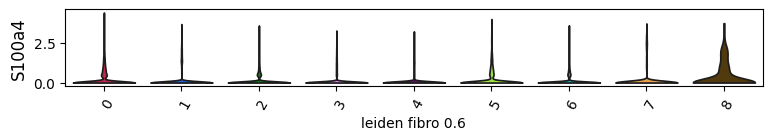

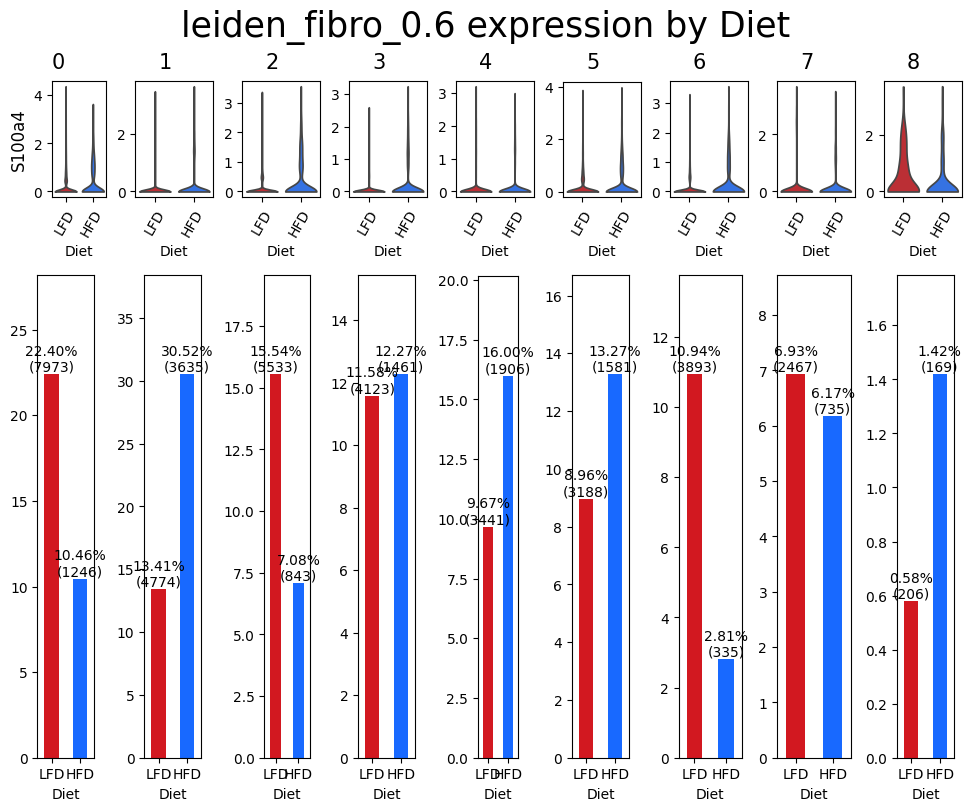

In [9]:
add_ons = [
    "S100a4",
]

for res in SELECT_RES:
    res_key = f"{CLUSTER_KEY}_{res:.1f}"
    plot_violinplot(adata_fibro, res_key, add_ons)
    plot_cluster_violinplot(adata_fibro, "Diet", res_key, add_ons, f=plt.figure(figsize=(8*1.2,8), layout="constrained"))

# Save/Load

In [ ]:
# save
clear_adata(adata_fibro, ["dendrogram", "colors"])
adata_fibro.write(SUBSETS_DIR / (CELLTYPE_ADDON + '.h5ad'))

In [3]:
# load
adata_fibro = sc.read_h5ad(SUBSETS_DIR / (CELLTYPE_ADDON + '.h5ad'))
adata_fibro

AnnData object with n_obs × n_vars = 47509 × 27381
    obs: 'Identifier', 'Dataset', 'n_genes', 'n_counts', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'Diet', 'Age', 'Sex', 'Depot', 'global_leiden_0.1', 'global_leiden_0.2', 'global_leiden_0.3', 'global_leiden_0.4', 'global_leiden_0.5', 'global_leiden_0.6', 'global_leiden_0.7', 'global_leiden_0.8', 'global_leiden_0.9', 'global_leiden_1.0', 'global_leiden_1.1', 'global_leiden_1.2', 'celltype_So2025', 'celltypist_So2025', 'celltype_Emont2022', 'celltypist_Emont2022', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'celltype', 'cloupe_barcode', 'total_counts_unknown', 'log1p_total_counts_unknown', 'pct_counts_unknown', 'leiden_fibro_0.2', 'leiden_fibro_0.4', 'leiden_fibro_0.6', 'leiden_fibro_0.8', 'leiden_fibro_0.1', 'leiden_fibro_0.3', 'leiden_fibro_0.5', 'leiden_fibro_0.7', 'leiden

# Sandbox

In [ ]:
# adata_fibro.obsm['LocalMAP_fibro_global'] = adata_fibro.obsm['LocalMAP_fibro'].copy()
# adata_fibro.obsm['UMAP_fibro_global'] = adata_fibro.obsm['UMAP_fibro'].copy()

# adata_fibro.obsp['neighbors_fibro_global_connectivities'] = adata_fibro.obsp['neighbors_fibro_connectivities'].copy()
# adata_fibro.obsp['neighbors_fibro_global_distances'] = adata_fibro.obsp['neighbors_fibro_distances'].copy()

# adata_fibro.uns['neighbors_fibro']['connectivities_key'] = 'neighbors_fibro_global_connectivities'
# adata_fibro.uns['neighbors_fibro']['distances_key'] = 'neighbors_fibro_global_distances'
# adata_fibro.uns['neighbors_fibro_global'] = adata_fibro.uns['neighbors_fibro'].copy()

# del adata_fibro.obsm['UMAP_fibro'], adata_fibro.obsm['LocalMAP_fibro'], adata_fibro.uns['neighbors_fibro'], adata_fibro.obsp['neighbors_fibro_connectivities'], adata_fibro.obsp['neighbors_fibro_distances']

In [ ]:
# pca_key = f"PCA-hvg_{CELLTYPE_ADDON}"
# FindVariableGenes(adata_fibro, "seurat_v3")
# PCA(adata_fibro, gene_mask="highly_variable", key=pca_key)
# Visualize(adata_fibro, key=CELLTYPE_ADDON, obsm=pca_key)
# Cluster(adata_fibro, CLUSTER_KEY, resolutions, neighbor_key=f"neighbors_{CELLTYPE_ADDON}")